# Phase 1
Training the teacher to avoid obstacles and get to the goal efficiently/quickly

In [ ]:
%cd ..
# need to be able to see environment
# this isn't working for some reason

/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/gridworld_v1


In [2]:
%pip install torch


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install tqdm
%pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
# os.chdir("gridworld_v1")

In [ ]:
# imports
from environment.custom_environment import GridWorldBase, TeacherWrapper
from agents.agents import TeacherAgent, ExperienceReplay
import tqdm
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import glob
import re

In [ ]:
# initialization
grid_size = 5
learning_rate = 0.001
initial_epsilon = 1
epsilon_decay = 0.995
final_epsilon = 0.01
num_filters_first_layer = 8
discount_factor = 0.99
episodes = 500
max_steps = 50
target_update_freq = 1000

goal_reward = 10
num_special_regions = 0
special_region_rewards = []

experience_capacity = 2000
batch_size = 64

base_env = GridWorldBase(grid_size, num_special_regions, goal_reward)
env = TeacherWrapper(base_env, None, special_region_rewards)
agent = TeacherAgent(base_env, learning_rate, initial_epsilon, epsilon_decay, final_epsilon, num_filters_first_layer, target_update_freq, discount_factor)

experience_replay = ExperienceReplay(capacity=experience_capacity, batch_size=batch_size)

In [7]:
# training
episode_total_rewards = []
losses = []
lengths = []

pbar = tqdm.tqdm(range(episodes), desc="Training")

for episode in pbar: 
    obs, info = env.reset()
    state = base_env.make_one_agent_grid("teacher")
    episode_reward = 0

    for step in range(max_steps): 
        action = agent.get_action(state)
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = base_env.make_one_agent_grid("teacher")

        experience_replay.add_experience(state, action, reward, next_state, terminated or truncated)
        if terminated or truncated: 
            lengths.append(step) # number of steps taken
            break

        if experience_replay.can_provide_sample(): 
            experiences = experience_replay.sample_batch()
            loss = agent.learn(experiences)
            losses.append(loss)
        
        episode_reward += reward
        state = next_state

        pbar.set_postfix(epsilon=f"{agent.epsilon:.3f}", steps=step)
    
        if episode % 100 == 0:
            pass # in the future I want to record some extra info here or smth
    
    episode_total_rewards.append(episode_reward)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Training: 100%|██████████| 500/500 [02:03<00:00,  4.04it/s, epsilon=0.010, steps=1] 


In [ ]:
base_dir = "models"
dirs = glob.glob(os.path.join(base_dir, "t_m_*"))
highest_num = 0
for d in dirs: 
    number = re.search(r't_m_(\num+)$', d)
    if number: 
        highest_num = max(highest_num, int(number.group(1)))

next_num = highest_num + 1
run_dir = os.path.join(base_dir, f"t_m_{next_num}")
os.makedirs(run_dir, exist_ok=True)

torch.save(agent.model.state_dict(), f'{run_dir}/model.pt')
with open(f'{run_dir}/hyperparameters.txt', 'w') as f: 
    f.write(
f"""grid_size = {grid_size}
learning_rate = {learning_rate}
initial_epsilon = {initial_epsilon}
epsilon_decay = {epsilon_decay}
final_epsilon = {final_epsilon}
num_filters_first_layer = {num_filters_first_layer}
discount_factor = {discount_factor}
episodes = {episodes}
max_steps = {max_steps}
target_update_freq = {target_update_freq}
goal_reward = {goal_reward}
num_special_regions = {num_special_regions}
special_region_rewards = {special_region_rewards}
experience_capacity = {experience_capacity}
batch_size = {batch_size}""")

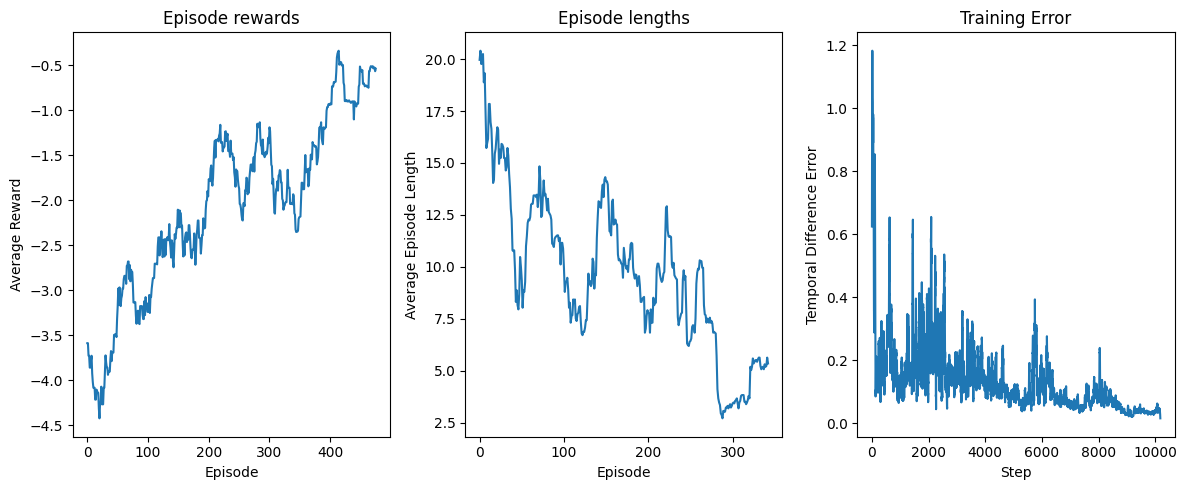

In [9]:
# https://gymnasium.farama.org/introduction/train_agent/
def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over this window
rolling_length = episodes//20
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    episode_total_rewards,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    lengths,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")


# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    losses,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.savefig(f'{run_dir}/plots.png')
plt.show()

In [ ]:
# load agent

In [ ]:
# test

agent.epsilon = 0
obs, info = env.reset()
state = base_env.make_grid()
base_env.render()
total_reward = 0

with open(f'{run_dir}/test_result.txt', 'w') as f:
    # code from claude for logging in file
    sys.stdout = f
    try:
        for step in range(max_steps):
            action = agent.get_action(state)
            obs, reward, terminated, truncated, info = env.step(action)
            next_state = base_env.make_one_agent_grid("teacher")
            total_reward += reward
            print(f"Step {step} | Action: {action} | Reward: {reward}")
            base_env.render()
            state = next_state
            if terminated or truncated:
                print(f"Done in {step+1} steps | Total reward: {total_reward}")
                break
    finally:
        sys.stdout = sys.__stdout__

['.', '.', '.', '.', '.']
['.', '.', '.', '.', '.']
['S', '.', '.', '.', '.']
['.', '.', '.', '.', 'G']
['.', '.', '.', '.', '.']



ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/.venv/lib/python3.13/site-packages/ipykernel/utils.py", line 60, in run_in_context
    return await asyncio.create_task(coro, context=context)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 621, in shell_main
    await self.dispatch_shell(msg, subshell_id=subshell_id)
  File "/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 491, in dispatch_shell
    sys.stdout.flush()
    ~~~~~~~~~~~~~~~~^^
ValueError: I/O operation on closed file.
